# imports

In [407]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from tqdm.auto import tqdm
import random
import os

import joblib # сэйв скалера

In [408]:
link_hist = '/Users/artemvorobchenko/Desktop/traiding_data/noHistory (2)/normalized-2026-01-02.csv'
link_profit = '/Users/artemvorobchenko/Desktop/traiding_data/noHistory (2)/profitable_trades_main.csv'

In [409]:
cols_noHistory = pd.read_csv(link_hist, nrows=1).columns

num_cols = [col for col in all_cols if 'symbol' not in col]

In [410]:
noHistory = pd.read_csv(link_hist, usecols=num_cols)
profit = pd.read_csv(link_profit)

# isnull stats
* дроп колонок, где пропуски составляют > 50%
* после заполним оставшиеся NaN предыдущими ненулевыми значениями (ffill)
* для колонок которые начинались с NaN, заполним следующими ненулевыми (bfill)

In [411]:
print(f'NaN: {round(noHistory.isna().sum().sum() / noHistory.size * 100, 2)} %')

#noHistory.isnull().mean() * 100

NaN: 19.31 %


In [412]:
noHistory_clear = noHistory.dropna(thresh=(len(noHistory) * 0.5), axis=1)
#noHistory_clear.columns[noHistory_clear.isnull().any()].tolist()

In [413]:
print(f'NaN: {round(noHistory_clear.isna().sum().sum() / noHistory_clear.size * 100, 2)} %')

NaN: 4.53 %


In [414]:
noHistory_clear = noHistory_clear.copy()

noHistory_clear.ffill(inplace=True)
noHistory_clear.bfill(inplace=True)

In [415]:
print(f'NaN: {noHistory_clear.isna().sum().sum() / noHistory_clear.size * 100}%')

NaN: 0.0%


# Train/valid/test

* 70% train
* 15% valid
* 15% test

* поиск уникальных индексов покупки (делается для того, чтобы при разбиении на train/valid/test одинаковые индексы не попали в разные выборки, и не произошла утечка), после оставим только индексы >= 15, чтобы мы могли учитывать полную историю в тензоре

* еще важный момент, расстояние между train/valid/test должны быть минимум в 15 объектов, иначе получится, что например в valid попадет кусок данных из train, для этого нам просто нужно прибавлять к концам интревалов наш window_size

In [416]:
profit = profit.sort_values("buy_row_idx").reset_index(drop=True)

In [417]:
unique_buy_idx = profit["buy_row_idx"].unique()
unique_buy_idx = unique_buy_idx[unique_buy_idx >= 15]
unique_buy_idx = sorted(unique_buy_idx)

In [418]:
n_states = len(unique_buy_idx)
window_size = 16

train_end_idx = int(n_states * 0.70)
valid_end_idx = int(n_states * 0.85)

train_states = unique_buy_idx[:train_end_idx]
valid_states = unique_buy_idx[train_end_idx + window_size : valid_end_idx]
test_states  = unique_buy_idx[valid_end_idx + window_size :]

# кол-во уникальных индексов, которые попадут train/valid/test
* так же посмотрим распределения CALL/PUT

In [419]:
print("Train states:", len(train_states))
print("Valid states:", len(valid_states))
print("Test states:", len(test_states))

Train states: 2702
Valid states: 563
Test states: 563


In [420]:
train_states_set = set(train_states)
valid_states_set = set(valid_states)
test_states_set  = set(test_states)

profit_train = profit[profit["buy_row_idx"].isin(train_states_set)].copy()
profit_valid = profit[profit["buy_row_idx"].isin(valid_states_set)].copy()
profit_test  = profit[profit["buy_row_idx"].isin(test_states_set)].copy()

In [421]:
profit.groupby("type")["buy_row_idx"].agg(["min", "max", "count"])

,min,max,count
type,,,
Temporal_CALL_1,10,4419,438898
Temporal_PUT_1,10,4418,302333


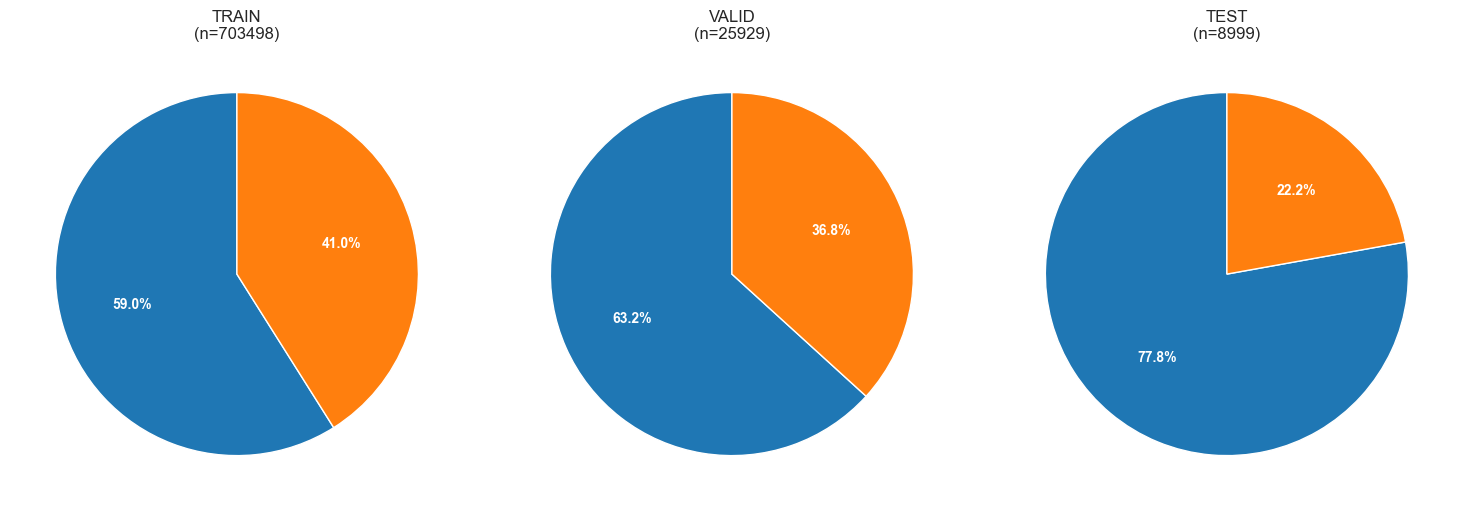

In [422]:
train_dist = profit_train["type"].value_counts()
valid_dist = profit_valid["type"].value_counts()
test_dist = profit_test["type"].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
distributions = [train_dist, valid_dist, test_dist]
titles = ['TRAIN', 'VALID', 'TEST']

for ax, dist, title in zip(axes, distributions, titles):
    wedges, texts, autotexts = ax.pie(dist,
                                       autopct='%1.1f%%',
                                       startangle=90,
                                       textprops={'fontsize': 10})
    ax.set_title(f'{title}\n(n={sum(dist)})')

    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

### не забыть в будущем чек кластера профит рэтио по put/call

# Функция создания окон
* берем 16 строк рынка и оборачиваем в тензор [samples , timesteps , features]


3828 уникальных индексов = 2702 + 563 + 563
на каждый индекс у нас приходится по временому срезу из 16 объектов

* 2702*16 = 43232
* 563*16  = 9008
* 563*16  = 9008

СУММА = 61248 уникальных строк для обучения энкодера


In [423]:
def build_tensor(shop_df, state_indices, window_size=16):
    samples = []
    used_states = []

    for t in state_indices:
        if t >= window_size - 1:
            seq = shop_df.iloc[t - window_size + 1 : t + 1].values
            samples.append(seq)
            used_states.append(t)

    X = np.stack(samples)

    return X, np.array(used_states)

In [424]:
X_train, train_states_used = build_tensor(noHistory_clear, train_states)
X_valid, valid_states_used = build_tensor(noHistory_clear, valid_states)
X_test, test_states_used = build_tensor(noHistory_clear, test_states)

# seed и зернышки

In [425]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# RobustScaler для нормализации
* Обучаем ток на Train, после трансформируем ко всем остальным

In [426]:
def scale_data(X_train, X_valid, X_test):
    scaler = RobustScaler()

    n_tr, t_s, n_f = X_train.shape
    n_va = X_valid.shape[0]
    n_te = X_test.shape[0]

    X_train_flat = X_train.reshape(-1, n_f)
    scaler.fit(X_train_flat)

    X_train_scale = scaler.transform(X_train_flat).reshape(n_tr, t_s, n_f)
    X_valid_scale = scaler.transform(X_valid.reshape(-1, n_f)).reshape(n_va, t_s, n_f)
    X_test_scale = scaler.transform(X_test.reshape(-1, n_f)).reshape(n_te, t_s, n_f)

    return X_train_scale, X_valid_scale, X_test_scale, scaler

# чето случилось с градиентами, хотя и так используется adamW и куча других регуляризацией, по приколу клипанул по границе и вылечилось

In [427]:
X_train_scale, X_valid_scale, X_test_scale, scaler = scale_data(X_train, X_valid, X_test)

CLIP_VAL = 10.0
X_train_scale = np.clip(X_train_scale, -CLIP_VAL, CLIP_VAL)
X_valid_scale = np.clip(X_valid_scale, -CLIP_VAL, CLIP_VAL)
X_test_scale = np.clip(X_test_scale, -CLIP_VAL, CLIP_VAL)

# save скайлер вайт

In [428]:
# scaler = joblib.load('robust_scaler.pkl') потом подгрузить

# to tensors

In [429]:
X_train_torch = torch.tensor(X_train_scale, dtype=torch.float32).transpose(1, 2)
X_valid_torch = torch.tensor(X_valid_scale, dtype=torch.float32).transpose(1, 2)
X_test_torch = torch.tensor(X_test_scale, dtype=torch.float32).transpose(1, 2)

# DataLoader

In [430]:
train_loader = DataLoader(TensorDataset(X_train_torch), batch_size=128, shuffle=True)
valid_loader = DataLoader(TensorDataset(X_valid_torch), batch_size=128, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_torch), batch_size=128, shuffle=False)

In [431]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используем устройство: {device}")

Используем устройство: cpu


In [432]:
class TCN(nn.Module):
    def __init__(self, n_features=702, latent_dim=32):
        super().__init__()

        #702to128
        self.compressor = nn.Conv1d(n_features, 128, kernel_size=1)

        self.enc_conv1 = nn.Conv1d(128, 64, kernel_size=3, padding=1, dilation=1)
        self.enc_conv2 = nn.Conv1d(64, 32, kernel_size=3, padding=2, dilation=2)

        self.flatten = nn.Flatten()
        self.fc_latent = nn.Linear(32 * 16, latent_dim)


        self.fc_expand = nn.Linear(latent_dim, 32 * 16)

        self.dec_conv1 = nn.ConvTranspose1d(32, 64, kernel_size=3, padding=1)
        self.dec_conv2 = nn.Conv1d(64, n_features, kernel_size=3, padding=1)

        self.activation = nn.SiLU()

    def encode(self, x):
        x = self.activation(self.compressor(x))
        x = self.activation(self.enc_conv1(x))
        x = self.activation(self.enc_conv2(x))
        return self.fc_latent(self.flatten(x))

    def forward(self, x):
        z = self.encode(x)
        x = self.activation(self.fc_expand(z)).view(-1, 32, 16)
        x = self.activation(self.dec_conv1(x))
        return self.dec_conv2(x)

In [433]:
def train_loop(model, train_loader, valid_loader, criterion, optimizer, device, epochs=30, save_path='best_tcn_model.pth'):
    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')

    main_bar = tqdm(range(epochs), desc="Training Progress")

    for epoch in main_bar:
        model.train()
        running_loss = 0.0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
            inputs = batch[0].to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            loss = criterion(outputs, inputs)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)

        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for batch in valid_loader:
                inputs = batch[0].to(device)
                outputs = model(inputs)
                v_loss = criterion(outputs, inputs)
                running_val_loss += v_loss.item()

        avg_val_loss = running_val_loss / len(valid_loader)
        scheduler.step(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), save_path)
            status_msg = "save"
        else:
            status_msg = "no_save"

        main_bar.set_postfix({
            't_Loss': f"{avg_train_loss:.5f}",
            'v_Loss': f"{avg_val_loss:.5f}",
            'stat': status_msg
        })

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)

    return history

In [434]:
LATENT_DIM = 32
LEARNING_RATE = 1e-3
EPOCHS = 50
BATCH_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [435]:
model = TCN(n_features=702, latent_dim=LATENT_DIM).to(DEVICE)

# AdamW , MAE , sheduler

In [436]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-2
)

loss = nn.L1Loss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [437]:
history = train_loop(
    model=model,
    train_loader=train_loader,
    valid_loader=valid_loader,
    criterion=loss,
    optimizer=optimizer,
    device=DEVICE,
    epochs=EPOCHS,
    save_path='best_tcn_model.pth'
)

Training Progress:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 2:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 3:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 4:   0%|          | 0/22 [00:00<?, ?it/s]

...

Epoch 46:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 47:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 48:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 49:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 50:   0%|          | 0/22 [00:00<?, ?it/s]

In [440]:
def plot_history(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Train MAE')
    plt.plot(history['val_loss'], label='Val MAE')
    plt.xlabel('Эпохи')
    plt.ylabel('Loss (MAE)')
    plt.legend()
    plt.grid(True)
    plt.show()

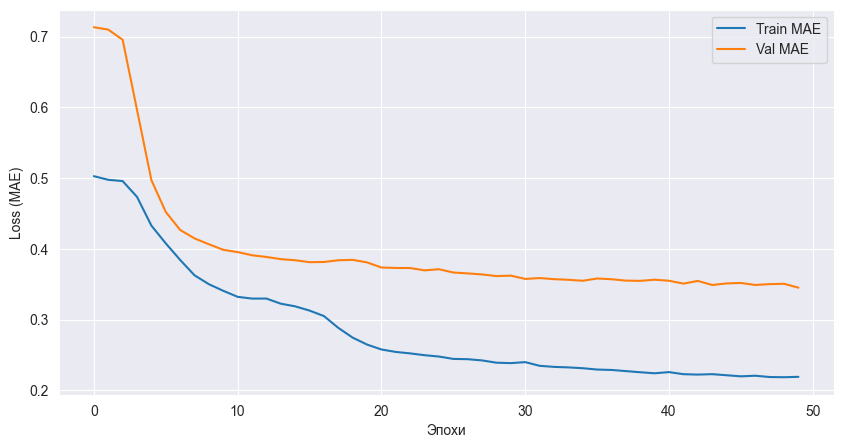

In [441]:
plot_history(history)

In [442]:
history

{'train_loss': [0.5027690787206996,
  0.49764254553751514,
  0.49585501985116437,
  0.4735554510896856,
  0.4329463297670538,
  0.4078278582204472,
  0.3844083087010817,
  0.3627158918163993,
  0.3501196083697406,
  0.34080046821724286,
  0.3322910571640188,
  0.329827219247818,
  0.3298584385351701,
  0.3226047605276108,
  0.31884458119219,
  0.312871438535777,
  0.30514970557256177,
  0.2884258045391603,
  0.2746419987895272,
  0.26484102417122235,
  0.2579005313190547,
  0.2544354193589904,
  0.2523635876449672,
  0.24982351606542413,
  0.2479290169748393,
  0.24458200349049133,
  0.24418711526827377,
  0.24243298376148398,
  0.23923565108667721,
  0.23862022500146518,
  0.2400312511758371,
  0.23484012281352823,
  0.23331894996491345,
  0.23258974674073132,
  0.23146058144894513,
  0.22954713214527478,
  0.22897882082245566,
  0.22736981917511334,
  0.22573388909751718,
  0.2242748811841011,
  0.2259236987341534,
  0.22300136698917908,
  0.22243106297471307,
  0.2230395877903158,
 